# Beam Trial Conversion Model

Beam launched its 14-day free trial on August 1, and since then the growth team has been asking the same question every week: which trials are going to convert, and can we know early enough to do something about the ones that won't?

This notebook builds a first model that predicts, from a trial's first 3 days of behavior, whether the user will convert to a paid plan at trial end. Predicting at day 3 leaves 11 days of runway to intervene on trials that look like they are going to die. The full context and the business case are in the model plan document that sits next to this notebook.

The data is one row per completed trial, pulled from the `ml.trial_snapshot` table that the data engineering team maintains. This notebook works from a CSV extract of that table.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

# !pip install xgboost

pd.set_option("display.max_columns", None)
%matplotlib inline

## Load data

In [2]:
df = pd.read_csv("trial_snapshot.csv")
df.head()

,trial_id,user_id,snapshot_date,trial_started_at,country,device_type,sessions_first_3d,active_days_first_3d,day1_share,listen_share_first_3d,total_minutes_first_3d,avg_session_minutes_first_3d,converted
0,1,27046,2026-09-24,2026-08-01,EU,iOS,6,2,0.667,0.333,81,13.50,0
1,2,27052,2026-09-24,2026-08-01,EU,Android,5,3,0.200,0.000,83,16.60,0
2,3,27053,2026-09-24,2026-08-01,Rest,Android,6,2,0.500,1.000,26,4.33,1
3,4,27054,2026-09-24,2026-08-01,US,iOS,0,0,0.000,0.000,0,0.00,0
4,5,27055,2026-09-24,2026-08-01,EU,iOS,20,2,0.900,0.250,158,7.90,0


In [3]:
print(df.shape)
print("conversion rate:", df["converted"].mean().round(4))

(1516, 13)
conversion rate: 0.5323


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1516 entries, 0 to 1515
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   trial_id                      1516 non-null   int64  
 1   user_id                       1516 non-null   int64  
 2   snapshot_date                 1516 non-null   str    
 3   trial_started_at              1516 non-null   str    
 4   country                       1516 non-null   str    
 5   device_type                   1516 non-null   str    
 6   sessions_first_3d             1516 non-null   int64  
 7   active_days_first_3d          1516 non-null   int64  
 8   day1_share                    1516 non-null   float64
 9   listen_share_first_3d         1516 non-null   float64
 10  total_minutes_first_3d        1516 non-null   int64  
 11  avg_session_minutes_first_3d  1516 non-null   float64
 12  converted                     1516 non-null   int64  
dtypes: float64(3),

## Quick exploration

In [5]:
df.groupby("converted")[["sessions_first_3d", "active_days_first_3d", "total_minutes_first_3d"]].mean().round(2)

,sessions_first_3d,active_days_first_3d,total_minutes_first_3d
converted,,,
0,7.29,2.07,76.78
1,11.74,2.81,125.66


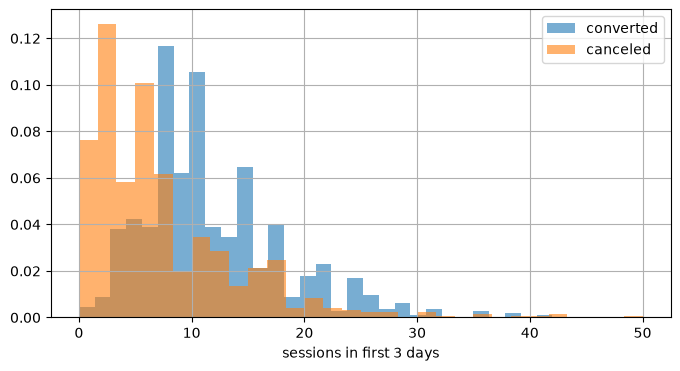

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
df[df.converted == 1]["sessions_first_3d"].hist(bins=30, alpha=0.6, label="converted", ax=ax, density=True)
df[df.converted == 0]["sessions_first_3d"].hist(bins=30, alpha=0.6, label="canceled", ax=ax, density=True)
ax.set_xlabel("sessions in first 3 days")
ax.legend()
plt.show()

In [7]:
# heavy day-1 users who then disappear look different from steady users
df["binge"] = (df["day1_share"] > 0.6) & (df["sessions_first_3d"] >= 3)
df.groupby("binge")["converted"].agg(["mean", "count"])

,mean,count
binge,,
False,0.620601,1165
True,0.239316,351


In [8]:
pd.crosstab(df["country"], df["converted"], normalize="index").round(3)

converted,0,1
country,,
EU,0.507,0.493
India,0.493,0.507
Rest,0.472,0.528
US,0.435,0.565


A few things stand out:

- Converters use the app roughly twice as much in the first 3 days, and they spread that usage across more days.
- The binge pattern is real: users who cram most of their usage into day 1 and then go quiet convert far less than steady users with the same total. Total sessions alone does not tell the whole story.
- Country differences are modest, but they stay in as features anyway.

## Features

In [9]:
def prep_features(data):
    X = data.drop(columns=["trial_id", "user_id", "snapshot_date", "trial_started_at", "binge", "converted"])
    X = pd.get_dummies(X, columns=["country", "device_type"])
    y = data["converted"]
    return X, y

X, y = prep_features(df)
X.shape

(1516, 13)

## Baseline: logistic regression

A quick logistic regression gives us something honest to compare the real model against.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_s, y_train)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_s)[:, 1])
print("logistic regression AUC:", round(lr_auc, 4))

logistic regression AUC: 0.8357


That is a decent baseline. XGBoost should be able to do better here, because the binge pattern above is exactly the kind of interaction a linear model cannot capture.

## XGBoost

XGBoost AUC: 0.8743


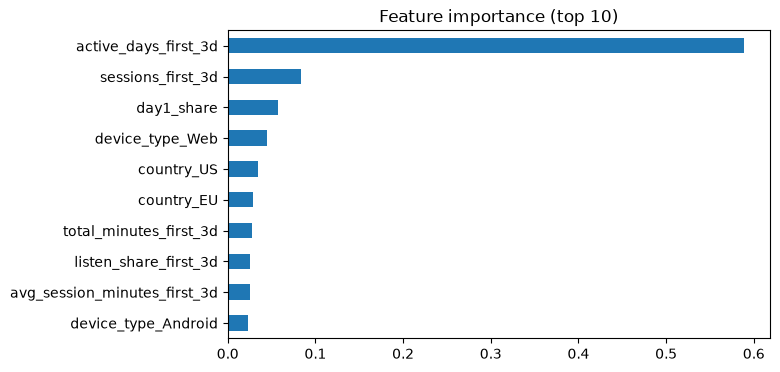

In [11]:
features = pd.get_dummies(df.drop(columns=["trial_id", "user_id", "snapshot_date", "trial_started_at", "binge", "converted"]),
                          columns=["country", "device_type"])
target = df["converted"]

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.25, stratify=target, random_state=42)

model = XGBClassifier(
    n_estimators=400,
    max_depth=3,
    learning_rate=0.05,
    min_child_weight=8,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="auc",
)
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]
print("XGBoost AUC:", round(roc_auc_score(y_test, probs), 4))

importances = pd.Series(model.feature_importances_, index=features.columns).sort_values()
importances.tail(10).plot(kind="barh", figsize=(7, 4), title="Feature importance (top 10)")
plt.show()

That is a clear improvement over the baseline, and the feature importances make sense: how much someone used the trial in the first days dominates, with the day-1 concentration and the listening share behind it.

## Evaluation

For the growth team, the interesting group is the trials the model says will NOT convert. Those are the ones worth an intervention, such as an onboarding email or a nudge toward audio content, while there is still trial time left.

In [12]:
preds = (probs >= 0.5).astype(int)
confusion_matrix(y_test, preds)

array([[138,  39],
       [ 39, 163]])

In [13]:
# who would we intervene on? everyone the model scores below 0.35
flagged = probs < 0.35
print("flagged for intervention:", flagged.sum(), "of", len(probs))
print("actual conversion rate among flagged:", round(y_test[flagged].mean(), 3))
print("actual conversion rate among the rest:", round(y_test[~flagged].mean(), 3))

flagged for intervention: 143 of 379
actual conversion rate among flagged: 0.154
actual conversion rate among the rest: 0.763


In [14]:
print(classification_report(y_test, preds, digits=3))

              precision    recall  f1-score   support

           0      0.780     0.780     0.780       177
           1      0.807     0.807     0.807       202

    accuracy                          0.794       379
   macro avg      0.793     0.793     0.793       379
weighted avg      0.794     0.794     0.794       379



The flagged group converts at a fraction of the rate of everyone else, which is exactly what an intervention list should look like. Where to put the cutoff depends on how many trials the lifecycle team can actually work through per week, so that threshold is their call rather than a modeling decision.

## Next steps

- The model looks good enough to pilot with the growth team.
- To be useful it has to score trials on day 3 while they are still live, which means it needs to run somewhere other than this notebook. The hand-off for deployment is the next conversation.
- The model will need retraining as more trial cohorts mature, especially once the traffic mix from the launch campaign settles.